<a href="https://colab.research.google.com/github/suji0311/Project1_Group_Study_Analysis/blob/main/%EB%B0%95%EC%88%98%EC%A7%80_1145_%EC%B5%9C%EC%A2%85%EA%B3%BC%EC%A0%9C_%EC%A0%9C%EC%B6%9C_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 문제 정의

본 분석의 목적은 조별활동 이탈(group_leave)에 영향을 미치는 요인을 분석하고,
이를 기반으로 조편성 전략을 제안하는 것이다.


# 2. 데이터 불러오기 및 기초 점검


In [ ]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


!pip install koreanize-matplotlib -q
import koreanize_matplotlib

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (8,5)
sns.set_style("whitegrid")


In [ ]:
# 파일 연결
import pandas as pd
df = pd.read_csv('/content/bda11 - analysis_final.csv', encoding='utf-8')


In [ ]:
# 한글 폰트 설치
!apt-get install -y fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 적용
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


데이터 구조 및 결측치를 확인한다.





In [ ]:
df = pd.read_csv('bda11 - analysis_final.csv')
df.info()
df.describe()
df.isnull().mean().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1314 entries, 0 to 1313
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   member_id        1314 non-null   int64  
 1   class_code       1314 non-null   int64  
 2   generation       1314 non-null   int64  
 3   group_number     1314 non-null   int64  
 4   group_master     1314 non-null   bool   
 5   on_offline       1314 non-null   object 
 6   group_leave      1314 non-null   bool   
 7   leave_point      1314 non-null   object 
 8   birthday         1274 non-null   float64
 9   birth_date       1272 non-null   object 
 10  age              1272 non-null   float64
 11  major1_1         1232 non-null   object 
 12  major1_2         855 non-null    object 
 13  job_domain       909 non-null    object 
 14  avg_point_m1     1280 non-null   float64
 15  avg_point_m2     1280 non-null   float64
 16  avg_point_m1m2   1280 non-null   float64
 17  delta_m2_m1   

,0
major1_2,0.349315
job_domain,0.308219
major1_1,0.062405
age,0.031963
birth_date,0.031963
birthday,0.030441
delta_m2_m1,0.025875
avg_point_m1m2,0.025875
avg_point_m2,0.025875
avg_point_m1,0.025875


결측치 분석 결과,
핵심 분석 변수(score_q, on_offline, leader_left 등)는
결측률이 5% 이하로 낮게 나타나 분석에 큰 문제가 없었다.

다만, major1_2와 job_domain 변수는 결측률이 30% 이상으로 높아
본 분석에서는 핵심 변수로 사용하지 않았다.

# 3. 기초 분석
## 3.1 전체 이탈 비율


In [ ]:
df['group_leave'].value_counts(normalize=True)


,proportion
group_leave,
False,0.868341
True,0.131659


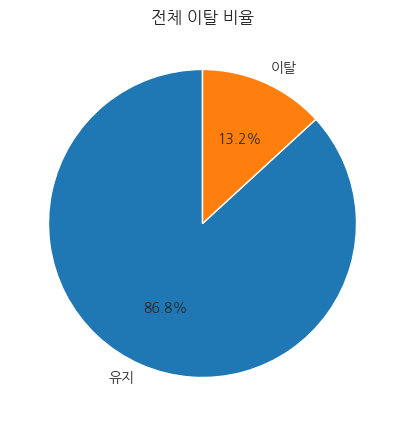

In [ ]:
leave_rate = df['group_leave'].value_counts(normalize=True)

labels = ['유지', '이탈']

plt.figure(figsize=(5,5))
plt.pie(leave_rate.values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90)
plt.title('전체 이탈 비율')
plt.show()


이탈 비율을 시각적으로 확인한다.


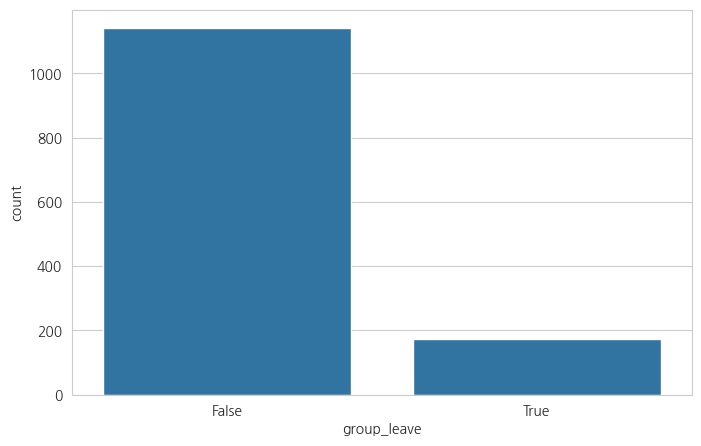

In [ ]:
sns.countplot(x='group_leave', data=df)
plt.title("")
plt.show()


In [ ]:
# 참여 방식별 전체 인원 수
df['on_offline'].value_counts()

# 참여 방식별 조장 수
df[df['group_master']==1]['on_offline'].value_counts()

# 참여 방식별 이탈 건수
df[df['group_leave']==1]['on_offline'].value_counts()


,count
on_offline,
온라인,86
오프라인,61
해당없음,22
온오프라인,4


# 4. 구조 리스크 정의

조장이 이탈한 조를 구조 리스크 조로 정의한다.

In [ ]:
leader_dropout_groups = df[
    (df['group_master'] == 1) & (df['group_leave'] == 1)
][['generation','class_code','group_number']]

df['leader_left'] = df.set_index(
    ['generation','class_code','group_number']
).index.isin(
    leader_dropout_groups.set_index(
        ['generation','class_code','group_number']
    ).index
).astype(int)

df['leader_left'].mean()


np.float64(0.10121765601217655)

# 4. 분위수 분석
초기 점수(avg_point_m1m2)를 기준으로 4분위로 구분한다.


In [ ]:
df['score_q'] = pd.qcut(df['avg_point_m1m2'], 4, labels=False)
df.groupby('score_q')['group_leave'].mean()


,group_leave
score_q,
0.0,0.179331
1.0,0.116418
2.0,0.080537
3.0,0.088050


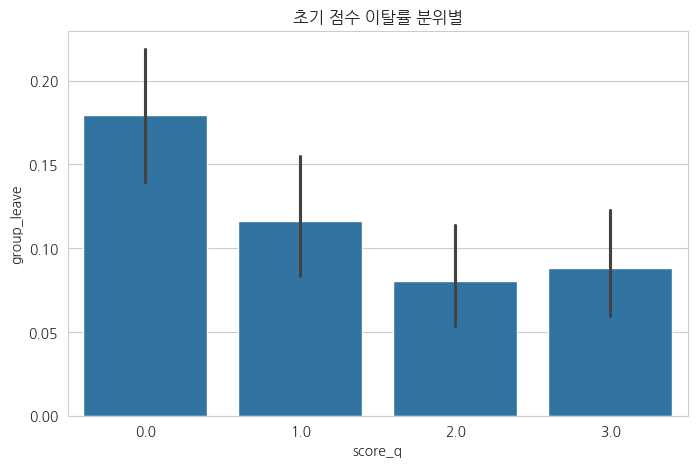

In [ ]:
sns.barplot(x='score_q', y='group_leave', data=df)
plt.title("초기 점수 이탈률 분위별")
plt.show()


초기 점수 하위 분위에서 이탈률이 높은지 확인한다.


# 5. 이상치 제거 (IQR 방식)


In [ ]:
Q1 = df['avg_point_m1m2'].quantile(0.25)
Q3 = df['avg_point_m1m2'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[
    (df['avg_point_m1m2'] >= Q1 - 1.5*IQR) &
    (df['avg_point_m1m2'] <= Q3 + 1.5*IQR)
]

print("Before:", df['group_leave'].mean())
print("After:", df_clean['group_leave'].mean())


Before: 0.13165905631659056
After: 0.12708719851576994


이상치 제거 전후 이탈률 변화를 비교한다.


# 6. 개인 이탈 리스크 분석



## 6.1 참여 방식별 이탈률


In [ ]:
df.groupby('on_offline')['group_leave'].mean()


,group_leave
on_offline,
오프라인,0.087393
온라인,0.152212
온오프라인,0.137931
해당없음,1.000000


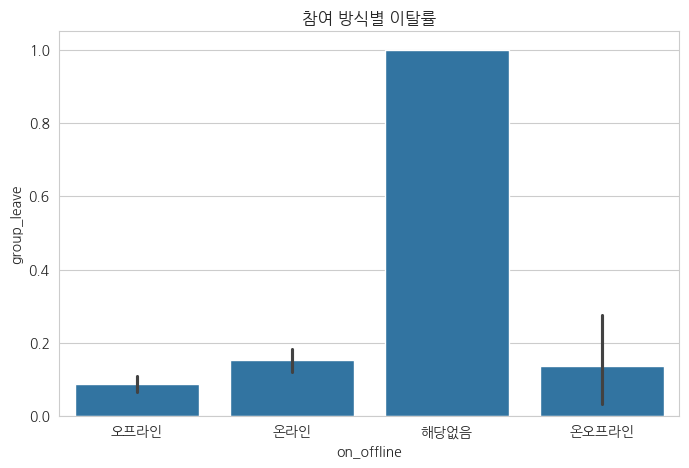

In [ ]:
sns.barplot(x='on_offline', y='group_leave', data=df)
plt.title("참여 방식별 이탈률")
plt.show()


## 6.2 반복그룹화


In [ ]:
# 1) score_q × on_offline
pd.pivot_table(
    df,
    values='group_leave',
    index='score_q',
    columns='on_offline',
    aggfunc='mean'
)

on_offline,오프라인,온라인,온오프라인,해당없음
score_q,,,,
0.0,0.094017,0.152174,0.333333,1.0
1.0,0.071429,0.158940,0.000000,1.0
2.0,0.083333,0.072000,0.000000,1.0
3.0,0.031818,0.197917,NaN,1.0


In [ ]:
# 2) score_q × has_leader
pd.pivot_table(
    df,
    values='group_leave',
    index='score_q',
    columns='has_leader',
    aggfunc='mean'
)


has_leader,False,True
score_q,,
0.0,1.0,0.142857
1.0,0.2,0.115152
2.0,NaN,0.080537
3.0,0.0,0.088608


In [ ]:
# 3) on_offline × has_leader
pd.pivot_table(
    df,
    values='group_leave',
    index='on_offline',
    columns='has_leader',
    aggfunc='mean'
)

has_leader,False,True
on_offline,,
오프라인,0.4,0.082849
온라인,1.0,0.144643
온오프라인,NaN,0.137931
해당없음,1.0,1.000000


6.4 연령 다양성 분위수 분석

In [ ]:
df['age_sd_q'] = pd.qcut(df['age_sd'], 4, labels=False)

df.groupby('age_sd_q')['group_leave'].mean()


,group_leave
age_sd_q,
0.0,0.114370
1.0,0.130435
2.0,0.129909
3.0,0.152381


In [ ]:
df.sample(200).to_csv("sample_data.csv", index=False)


6.5 직무 다양성 분석

# 7. 구조 리스크 분석 (조장 이탈 중심)


In [ ]:
# 조장 이탈률
df[df['group_master']==1]['group_leave'].mean()

np.float64(0.10410094637223975)

In [ ]:
# 온라인/오프라인별 조장 이탈
df[df['group_master']==1].groupby('on_offline')['group_leave'].mean()

,group_leave
on_offline,
오프라인,0.072289
온라인,0.132867
온오프라인,0.142857
해당없음,1.000000


In [ ]:
# 초기 점수 분위수별 조장 이탈
df[df['group_master']==1].groupby('score_q')['group_leave'].mean()

,group_leave
score_q,
0.0,0.171053
1.0,0.087500
2.0,0.026667
3.0,0.051948


##조장 이탈의 원인 분석

In [ ]:
df[df['group_master']==1].groupby('score_q')['group_leave'].mean()
df[df['group_master']==1].groupby('on_offline')['group_leave'].mean()
df[df['group_master']==1].groupby('age_sd_q')['group_leave'].mean()


,group_leave
age_sd_q,
0.0,0.078652
1.0,0.106667
2.0,0.090909
3.0,0.135135


##조장 이탈이 실제로 파괴적 영향이 있는가?

In [ ]:
df.groupby('leader_left')['group_leave'].mean()


,group_leave
leader_left,
0,0.083827
1,0.556391


#가설검증
##1.초기 점수
하위 25% → 이탈률 약 17~18%

상위 구간 → 8~9%

✔ 가장 일관된 패턴  
✔ 개인 리스크 + 조장 리스크 모두와 연결됨  
→ 근본 원인 후보

##2.온라인 vs 오프라인

온라인 이탈률 ≈ 15%

오프라인 ≈ 8%

✔ 표본도 충분  
✔ 거의 2배 차이

→ 환경 요인으로 작동 가능

##3.3번 축: 조장 이탈 (구조 리스크)

조장 이탈 발생 시 전체 이탈률 55%

미발생 조는 8%

✔ 가장 “파괴적 영향” 변수  
✔ 그러나 원인이라기보다 “증폭 요인”

In [ ]:
# 참여 방식별 초기 점수 평균
df.groupby('on_offline')['avg_point_m1m2'].mean()


,avg_point_m1m2
on_offline,
오프라인,2.102549
온라인,1.422073
온오프라인,0.874138
해당없음,0.739818


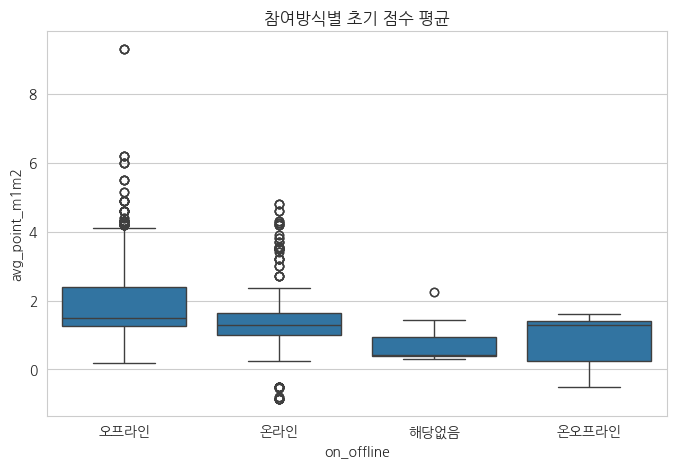

In [ ]:
#시각화
sns.boxplot(x='on_offline', y='avg_point_m1m2', data=df)
plt.title("참여방식별 초기 점수 평균")
plt.show()


In [ ]:
#분위수 분포 비교우선
pd.crosstab(df['on_offline'], df['score_q'], normalize='index')


score_q,0.0,1.0,2.0,3.0
on_offline,,,,
오프라인,0.173848,0.249629,0.249629,0.326895
온라인,0.330935,0.271583,0.224820,0.172662
온오프라인,0.413793,0.448276,0.137931,0.000000
해당없음,0.727273,0.136364,0.045455,0.090909


#가설검증

H1: 초기 점수 분위수와 이탈 여부는 독립이다.  
H2: 참여 방식(온라인/오프라인)과 이탈 여부는 독립이다.  
H3: 조장 이탈 발생 여부와 전체 이탈은 독립이다.  

  


---



귀무가설(H0): 두 변수는 독립이다.  
대립가설(H1): 두 변수는 독립이 아니다.

##H1 – 초기 점수와 이탈 (카이제곱)

In [ ]:
import scipy.stats as stats

# 교차표
ct1 = pd.crosstab(df['score_q'], df['group_leave'])

chi2_1, p_1, dof_1, exp_1 = stats.chi2_contingency(ct1)

print("H1 Chi-square:", chi2_1)
print("H1 p-value:", p_1)


H1 Chi-square: 18.762003057843742
H1 p-value: 0.00030619066256595243


##H2 – 온라인 vs 오프라인

In [ ]:
import scipy.stats as stats

df_h2 = df[df['on_offline'].isin(['온라인','오프라인'])]

ct2 = pd.crosstab(df_h2['on_offline'], df_h2['group_leave'])

chi2_2, p_2, dof_2, exp_2 = stats.chi2_contingency(ct2)

print("H2 Chi-square:", chi2_2)
print("H2 p-value:", p_2)

H2 Chi-square: 12.134301115742751
H2 p-value: 0.0004950281649626821


##H3 – 조장 이탈과 전체 이탈

In [ ]:
ct3 = pd.crosstab(df['leader_left'], df['group_leave'])

chi2_3, p_3, dof_3, exp_3 = stats.chi2_contingency(ct3)

print("H3 Chi-square:", chi2_3)
print("H3 p-value:", p_3)


H3 Chi-square: 229.38424796926225
H3 p-value: 8.12135697153688e-52


##결과 해석

## H1: 초기 점수와 이탈

카이제곱 검정 결과  
Chi-square = 18.76  
p-value = 0.000306  

p-value < 0.01로 나타나 귀무가설을 기각한다.  
초기 점수 분위수와 이탈 여부 사이에는 통계적으로 유의한 관계가 존재한다.  
특히 하위 분위에서 이탈률이 높게 나타났다.

---

## H2: 온라인 vs 오프라인

Chi-square = 12.13  
p-value = 0.000495  

p-value < 0.01로 나타나 귀무가설을 기각한다.  
참여 방식과 이탈 여부는 통계적으로 유의한 관계가 있다.  
온라인 참여자의 이탈률이 오프라인보다 높게 나타났다.

---

## H3: 조장 이탈과 전체 이탈

Chi-square = 229.38  
p-value ≈ 8.1e-52  

극도로 낮은 p-value로 귀무가설을 강하게 기각한다.  
조장 이탈은 조 전체 이탈과 매우 강한 연관을 가진다.  
조장 이탈이 발생한 조에서 이탈률이 급격히 증가하였다.

#로지스틱 회귀 분석

종속변수(group_leave)는 이탈 여부(0/1)로 구성된 이진 변수이므로,
연속형 종속변수를 가정하는 선형회귀 대신
이탈 확률을 직접 모델링할 수 있는 로지스틱 회귀를 적용하였다.

종속변수: group_leave  
독립변수: score_q, on_offline, leader_left

##8.1 데이터 전처리 (더미변수 생성)

In [ ]:
import statsmodels.api as sm
import pandas as pd

# df에서 필요한 컬럼(score_q, on_offline, group_leave, leader_left)을 선택하여 df_model 생성
# score_q는 이미 df에 추가되어 있어야 함 (f_FvHyyl0uB2 셀 확인)
df_model = df[['score_q', 'on_offline', 'group_leave', 'leader_left']].copy()

# '온라인' 또는 '오프라인' 참여 방식만 필터링
df_model = df_model[df_model['on_offline'].isin(['온라인','오프라인'])]

# 결측치 제거
# score_q는 avg_point_m1m2의 NaN으로 인해 NaN이 될 수 있으므로 제거
# group_leave, on_offline, leader_left 컬럼에도 NaN이 없어야 함
df_model.dropna(subset=['score_q', 'on_offline', 'group_leave', 'leader_left'], inplace=True)

# 온라인/오프라인 더미 변수 생성
df_model = pd.get_dummies(df_model, columns=['on_offline'], drop_first=True)

# 독립변수 설정 for Model 1
X1 = df_model[['score_q', 'on_offline_온라인']]
X1 = sm.add_constant(X1)

# 종속변수 설정
y = df_model['group_leave']

##8.2 모델 1 (초기 점수 + 온라인)

In [ ]:
# 불리언 종속변수를 정수(0 또는 1)로 변환
y_numeric = y.astype(int)

# X1 DataFrame의 불리언 컬럼을 정수(0 또는 1)로 변환
X1_numeric = X1.copy() # 원본 X1을 변경하지 않기 위해 복사본 사용
if 'on_offline_온라인' in X1_numeric.columns and X1_numeric['on_offline_온라인'].dtype == 'bool':
    X1_numeric['on_offline_온라인'] = X1_numeric['on_offline_온라인'].astype(int)

model1 = sm.Logit(y_numeric, X1_numeric).fit()
print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.317898
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            group_leave   No. Observations:                 1229
Model:                          Logit   Df Residuals:                     1226
Method:                           MLE   Df Model:                            2
Date:                Wed, 18 Feb 2026   Pseudo R-squ.:                 0.02797
Time:                        11:18:35   Log-Likelihood:                -390.70
converged:                       True   LL-Null:                       -401.94
Covariance Type:            nonrobust   LLR p-value:                 1.311e-05
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.4642      0.211    -11.694      0.000      -2.877      -2.051
score_q          

##8.3 모델 2 (조장 이탈 포함)

In [ ]:
X2 = df_model[['score_q', 'on_offline_온라인', 'leader_left']]
X2 = sm.add_constant(X2)

# 종속변수 y를 숫자형으로 변환
y_numeric = y.astype(int)

# 독립변수 X2에서 불리언 컬럼을 숫자형으로 변환 (만약 있다면)
X2_numeric = X2.copy()
if 'on_offline_온라인' in X2_numeric.columns and X2_numeric['on_offline_온라인'].dtype == 'bool':
    X2_numeric['on_offline_온라인'] = X2_numeric['on_offline_온라인'].astype(int)
# leader_left도 혹시 모를 불리언 타입을 위해 명시적으로 int로 변환
if 'leader_left' in X2_numeric.columns and X2_numeric['leader_left'].dtype == 'bool':
    X2_numeric['leader_left'] = X2_numeric['leader_left'].astype(int)

model2 = sm.Logit(y_numeric, X2_numeric).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.277168
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            group_leave   No. Observations:                 1229
Model:                          Logit   Df Residuals:                     1225
Method:                           MLE   Df Model:                            3
Date:                Wed, 18 Feb 2026   Pseudo R-squ.:                  0.1525
Time:                        11:18:35   Log-Likelihood:                -340.64
converged:                       True   LL-Null:                       -401.94
Covariance Type:            nonrobust   LLR p-value:                 2.126e-26
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.9011      0.230    -12.622      0.000      -3.352      -2.451
score_q          

In [ ]:
# 개인정보 컬럼 제거
cols_to_drop = [
    'member_id',
    'birthday',
    'birth_date',
    'age',
    'major1_1',
    'major1_2',
    'job_domain'
]

df_public = df.drop(columns=cols_to_drop)

# 혹시 남은 object형 민감정보 있는지 확인
print(df_public.select_dtypes(include='object').columns)

# 공개용 CSV 저장
df_public.to_csv("analysis_public_sample.csv", index=False)


Index(['on_offline', 'leave_point'], dtype='object')


In [ ]:
df_public.sample(300, random_state=42).to_csv(
    "analysis_public_sample.csv",
    index=False
)


In [ ]:
import numpy as np

# 오즈비 계산
params = model2.params
conf = model2.conf_int()

# 오즈비와 신뢰구간 변환
odds_ratio = np.exp(params)
conf['OR_lower'] = np.exp(conf[0])
conf['OR_upper'] = np.exp(conf[1])

result_table = pd.DataFrame({
    'Odds Ratio': odds_ratio,
    'Lower 95% CI': conf['OR_lower'],
    'Upper 95% CI': conf['OR_upper'],
    'p-value': model2.pvalues
})

result_table


,Odds Ratio,Lower 95% CI,Upper 95% CI,p-value
const,0.054961,0.035027,0.086239,1.606293e-36
score_q,0.994348,0.826474,1.196322,9.520968e-01
on_offline_온라인,1.692298,1.108037,2.584636,1.490181e-02
leader_left,11.930318,7.447116,19.112428,6.313199e-25


# 9. 의사결정나무 분석

이탈 발생 조건을 직관적으로 확인하기 위해
의사결정나무 분류 모델을 적용한다.

종속변수: group_leave  
독립변수: score_q, on_offline, leader_left

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
import matplotlib.pyplot as plt

# 분석용 데이터 준비
df_tree = df.copy()
df_tree = df_tree[df_tree['on_offline'].isin(['온라인','오프라인'])]

df_tree = pd.get_dummies(df_tree, columns=['on_offline'], drop_first=True)

X = df_tree[['score_q', 'on_offline_온라인', 'leader_left']]
y = df_tree['group_leave']

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [ ]:
#모델학습
clf = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

clf.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

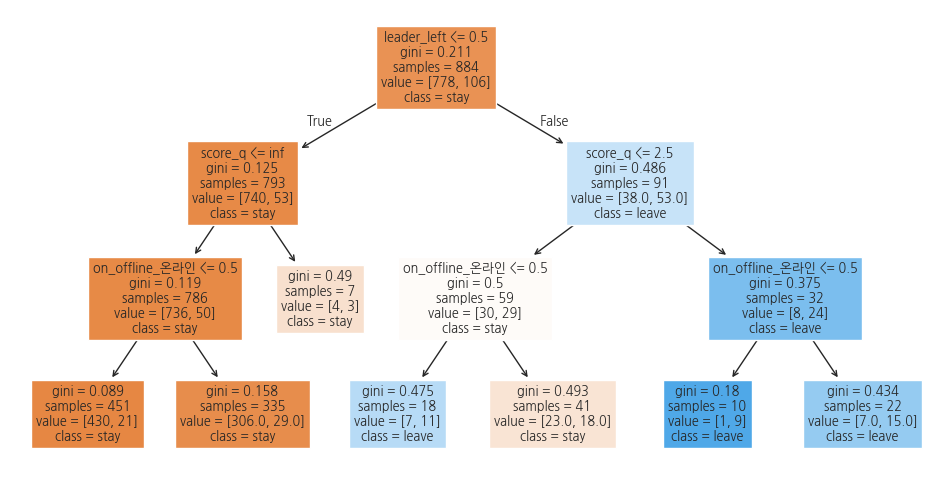

In [ ]:
plt.figure(figsize=(12,6))
tree.plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["stay","leave"],
    filled=True
)
plt.show()


# . 상관 분석


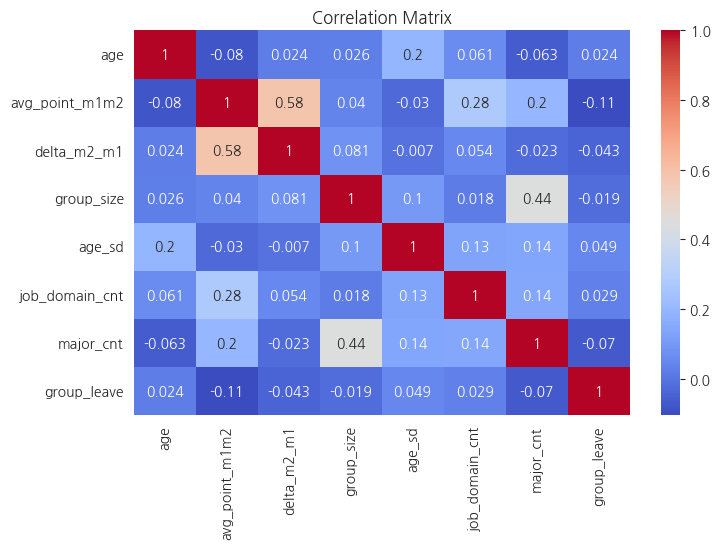

In [ ]:
num_cols = [
    'age',
    'avg_point_m1m2',
    'delta_m2_m1',
    'group_size',
    'age_sd',
    'job_domain_cnt',
    'major_cnt'
]

corr = df[num_cols + ['group_leave']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
